In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install --upgrade "dask[dataframe]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2025.5.0
    Uninstalling dask-2025.5.0:
      Successfully uninstalled dask-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2025.5.0 requires dask==2025.5.0, but you have dask 2025.9.0 which is incompatible.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.9.0 which is incompatible.


In [3]:
!pip install --upgrade "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: distributed
    Found existing installation: distributed 2025.5.0
    Uninstalling distributed-2025.5.0:
      Successfully uninstalled distributed-2025.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2025.9.0 which is incompatible.
rapids-dask-dependency 25.6.0 requires distributed==2025.5.0, but you have distributed 2025.9.0 which is incompatible.


In [4]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

from dask.distributed import Client, LocalCluster

# Existe integração com pandas, então customização da configuração do pandas também funciona aqui

# Não limitar a largura das colunas apresentadas
pd.options.display.max_colwidth = None
# Não usar a notação científica (ex: 6.125000e-02) e usar 6 casas decimais (ex: 0.061250)
pd.options.display.float_format = "{:.6f}".format
# Não utilizar matplotlib como engine de gráficos e usar plotly
pd.options.plotting.backend = "plotly"

In [5]:
# Criar cluster local anexado ao kernel do notebook
cluster = LocalCluster()
client = Client(cluster)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39427
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36445'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45511'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44799 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44799
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:56700
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38839 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38839
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39427,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44799,Total threads: 1
Dashboard: http://127.0.0.1:37047/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:36445,


In [ ]:
# client.close()
# cluster.close()

## Explorando os datasets

In [6]:
ROOT_DATA_PATH = "drive/MyDrive/data/ml-25m"

In [7]:
movies_df = dd.read_csv(f"{ROOT_DATA_PATH}/movies.csv") #Adiciona a tarefa no DAG
movies_df #Mostra apenas um preview do DAG

,movieId,title,genres
npartitions=1,,,
,int64,string,string
,...,...,...


In [8]:
movies_df.head() #executa parcialmente o DAG, só o suficiente para pegar N linhas

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
len(movies_df)# Executa o DAG inteiro

62423

In [32]:
type(movies_df)

dask.dataframe.dask_expr._collection.DataFrame

In [33]:
type(movies_df.head())

pandas.core.frame.DataFrame

In [10]:
tags_df = dd.read_csv(f"{ROOT_DATA_PATH}/tags.csv")
tags_df

,userId,movieId,tag,timestamp
npartitions=1,,,,
,int64,int64,string,int64
,...,...,...,...


In [11]:
tags_df.head()

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


In [12]:
len(tags_df)

1093360

In [13]:
# Converter os valores da coluna 'timestamp' de epoch em segundos para datetime
tags_df['timestamp'] = dd.to_datetime(tags_df['timestamp'], unit='s')# Transformações adicionam tarefas ao DAG
tags_df['userId'] = tags_df['userId'].astype(int)
tags_df['movieId'] = tags_df['movieId'].astype(int)
tags_df

,userId,movieId,tag,timestamp
npartitions=1,,,,
,int64,int64,string,datetime64[ns]
,...,...,...,...


In [14]:
tags_df.head()

,userId,movieId,tag,timestamp
0,3,260,classic,2015-08-13 13:25:55
1,3,260,sci-fi,2015-08-13 13:24:16
2,4,1732,dark comedy,2019-11-16 22:33:18
3,4,1732,great dialogue,2019-11-16 22:33:24
4,4,7569,so bad it's good,2019-11-16 22:30:55


In [15]:
ratings_df = dd.read_csv(f"{ROOT_DATA_PATH}/ratings.csv")
ratings_df

,userId,movieId,rating,timestamp
npartitions=10,,,,
,int64,int64,float64,int64
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


In [16]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,296,5.000000,1147880044
1,1,306,3.500000,1147868817
2,1,307,5.000000,1147868828
3,1,665,5.000000,1147878820
4,1,899,3.500000,1147868510


In [17]:
len(ratings_df)

25000095

In [18]:
# Converter os valores da coluna 'timestamp' de epoch em segundos para datetime
ratings_df['timestamp'] = dd.to_datetime(ratings_df['timestamp'], unit='s')
ratings_df['userId'] = ratings_df['userId'].astype(int)
ratings_df['movieId'] = ratings_df['movieId'].astype(int)
ratings_df

,userId,movieId,rating,timestamp
npartitions=10,,,,
,int64,int64,float64,datetime64[ns]
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


In [19]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,296,5.000000,2006-05-17 15:34:04
1,1,306,3.500000,2006-05-17 12:26:57
2,1,307,5.000000,2006-05-17 12:27:08
3,1,665,5.000000,2006-05-17 15:13:40
4,1,899,3.500000,2006-05-17 12:21:50


In [20]:
dd.read_csv(f"{ROOT_DATA_PATH}/links.csv")

,movieId,imdbId,tmdbId
npartitions=1,,,
,int64,int64,int64
,...,...,...


In [21]:
dd.read_csv(f"{ROOT_DATA_PATH}/links.csv").isnull().sum().compute()

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+--------+---------+----------+
| Column | Found   | Expected |
+--------+---------+----------+
| tmdbId | float64 | int64    |
+--------+---------+----------+

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'tmdbId': 'float64'}

to the call to `read_csv`/`read_table`.

Alternatively, provide `assume_missing=True` to interpret
all unspecified integer columns as floats.

In [22]:
# Existem filmes sem valor na coluna 'tmdbId', por esse motivo a coluna não pode ser do tipo int
links_df = dd.read_csv(f'{ROOT_DATA_PATH}/links.csv',
                       dtype={'movieId': int, 'imdbId': int},
                       assume_missing=True)
links_df

,movieId,imdbId,tmdbId
npartitions=1,,,
,int64,int64,float64
,...,...,...


In [23]:
links_df.isnull().sum().compute()

,0
movieId,0
imdbId,0
tmdbId,107


In [24]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.000000
1,2,113497,8844.000000
2,3,113228,15602.000000
3,4,114885,31357.000000
4,5,113041,11862.000000


In [25]:
len(links_df)

62423

In [26]:
gtags_df = dd.read_csv(f'{ROOT_DATA_PATH}/genome-tags.csv')
gtags_df

,tagId,tag
npartitions=1,,
,int64,string
,...,...


In [27]:
gtags_df.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


In [28]:
len(gtags_df)

1128

In [29]:
gscores_df = dd.read_csv(f'{ROOT_DATA_PATH}/genome-scores.csv')
gscores_df

,movieId,tagId,relevance
npartitions=6,,,
,int64,int64,float64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [30]:
gscores_df.head()

,movieId,tagId,relevance
0,1,1,0.028750
1,1,2,0.023750
2,1,3,0.062500
3,1,4,0.075750
4,1,5,0.140750


In [31]:
len(gscores_df)

15584448

## Executando merge de dados

In [ ]:
# Calculando total de linhas
len(movies_df)

62423

In [ ]:
len(links_df)

62423

In [ ]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.000000
1,2,113497,8844.000000
2,3,113228,15602.000000
3,4,114885,31357.000000
4,5,113041,11862.000000


In [34]:
# Criando operação de merge entre filmes e links
merged_df = dd.merge(movies_df, links_df, on='movieId', how='inner')
merged_df

,movieId,title,genres,imdbId,tmdbId
npartitions=1,,,,,
,int64,string,string,int64,float64
,...,...,...,...,...


In [35]:
merged_df.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.000000


In [36]:
len(merged_df)

62423

In [37]:
# Uma forma alternativa de fazer merge seria utilizando um dos dataframes
movies_df = movies_df.merge(links_df, on='movieId', how='inner')
movies_df.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.000000


In [ ]:
len(movies_df)

62423

## Quais são os top 10 filmes mais avaliados?

In [38]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,296,5.000000,2006-05-17 15:34:04
1,1,306,3.500000,2006-05-17 12:26:57
2,1,307,5.000000,2006-05-17 12:27:08
3,1,665,5.000000,2006-05-17 15:13:40
4,1,899,3.500000,2006-05-17 12:21:50


In [ ]:
type(ratings_df.head())

pandas.core.frame.DataFrame

In [ ]:
type(ratings_df)

dask.dataframe.dask_expr._collection.DataFrame

In [39]:
ratings_df

,userId,movieId,rating,timestamp
npartitions=10,,,,
,int64,int64,float64,datetime64[ns]
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


In [40]:
%%time

len(ratings_df)

CPU times: user 523 ms, sys: 78.1 ms, total: 601 ms
Wall time: 11.5 s


25000095

In [41]:
%%time

# Calcular os top 10 filmes com maior quantidade de avaliações
df = ratings_df[['movieId', 'rating']].groupby('movieId')\
  ['rating']\
  .count()\
  .rename('ratings_count')\
  .nlargest(10)\
  .persist() # Para salvar o df computado na memória RAM dos workers. Sai imediatamente.

CPU times: user 51.2 ms, sys: 6.8 ms, total: 58 ms
Wall time: 66.5 ms


In [42]:
%%time

df.max().compute() # Esse comando aguarda o cáculo da célula anterior terminar

CPU times: user 352 ms, sys: 35.4 ms, total: 387 ms
Wall time: 7.1 s


81491

In [43]:
%%time

df.max().compute() # Uma vez persistido em RAM o mesmo comando é mais rápido

CPU times: user 17.4 ms, sys: 650 µs, total: 18.1 ms
Wall time: 29.1 ms


81491

In [44]:
%%time

df.compute()

CPU times: user 11.8 ms, sys: 0 ns, total: 11.8 ms
Wall time: 15 ms


,ratings_count
movieId,
356,81491
318,81482
296,79672
593,74127
2571,72674
260,68717
480,64144
527,60411
110,59184


In [45]:
movies_df[['movieId', 'title']].compute()

,movieId,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3,Grumpier Old Men (1995)
3,4,Waiting to Exhale (1995)
4,5,Father of the Bride Part II (1995)
...,...,...
62418,209157,We (2018)
62419,209159,Window of the Soul (2001)
62420,209163,Bad Poems (2018)
62421,209169,A Girl Thing (2001)


In [ ]:
df.compute()\
  .reset_index()\
  .merge(
      movies_df[['movieId', 'title']].compute(), # Atenção, essa linha pode estourar a memória do client
      on='movieId',
      how='inner'
  )\
  .set_index('movieId')

,ratings_count,title
movieId,,
356,81491,Forrest Gump (1994)
318,81482,"Shawshank Redemption, The (1994)"
296,79672,Pulp Fiction (1994)
593,74127,"Silence of the Lambs, The (1991)"
2571,72674,"Matrix, The (1999)"
260,68717,Star Wars: Episode IV - A New Hope (1977)
480,64144,Jurassic Park (1993)
527,60411,Schindler's List (1993)
110,59184,Braveheart (1995)


In [46]:
df.compute().reset_index()

,movieId,ratings_count
0,356,81491
1,318,81482
2,296,79672
3,593,74127
4,2571,72674
5,260,68717
6,480,64144
7,527,60411
8,110,59184
9,2959,58773


In [47]:
# Solução alternativa mais segura porque o merge acontece de maneira distribuída no cluster
# Assim, somente o resultado final que terá 10 linhas será enviado para o client

df = movies_df[['movieId', 'title']].merge(
    df.compute().reset_index(),
    on='movieId',
    how='inner'
).sort_values(by='ratings_count', ascending=False)\
  .compute()\
  .set_index('movieId') # O set_index do Dask Dataframe ordena os dados por padrão, por isso usei o do pandas
df

,title,ratings_count
movieId,,
356,Forrest Gump (1994),81491
318,"Shawshank Redemption, The (1994)",81482
296,Pulp Fiction (1994),79672
593,"Silence of the Lambs, The (1991)",74127
2571,"Matrix, The (1999)",72674
260,Star Wars: Episode IV - A New Hope (1977),68717
480,Jurassic Park (1993),64144
527,Schindler's List (1993),60411
110,Braveheart (1995),59184


from matplotlib import pyplot as plt
df['ratings_count'].plot(kind='hist', bins=20, title='ratings_count')
plt.gca().spines[['top', 'right',]].set_visible(False)

TypeError: line() got an unexpected keyword argument 'figsize'

from matplotlib import pyplot as plt
df['ratings_count'].plot(kind='line', figsize=(8, 4), title='ratings_count')
plt.gca().spines[['top', 'right']].set_visible(False)

## Atividade Turma

### Quais são os top 10 filmes com maior total da soma das avaliações?

In [48]:
%%time

df_task = ratings_df[['movieId', 'rating']].groupby('movieId')\
  ['rating']\
  .sum()\
  .rename('ratings_sum')\
  .nlargest(10)\
  .reset_index()
df_task.compute()

CPU times: user 739 ms, sys: 66.1 ms, total: 805 ms
Wall time: 10.6 s


,movieId,ratings_sum
0,318,359627.000000
1,296,333739.000000
2,356,329876.500000
3,593,307726.500000
4,2571,301895.000000
5,260,283127.000000
6,527,256600.500000
7,2959,248510.500000
8,1196,237711.000000
9,50,237207.500000


In [49]:
%%time

movies_df[['movieId', 'title']].merge(
    df_task,
    on='movieId',
    how='inner'
).sort_values(by='ratings_sum', ascending=False)\
  .compute()

CPU times: user 931 ms, sys: 93.3 ms, total: 1.02 s
Wall time: 13.1 s


,movieId,title,ratings_sum
3,318,"Shawshank Redemption, The (1994)",359627.000000
2,296,Pulp Fiction (1994),333739.000000
4,356,Forrest Gump (1994),329876.500000
6,593,"Silence of the Lambs, The (1991)",307726.500000
8,2571,"Matrix, The (1999)",301895.000000
1,260,Star Wars: Episode IV - A New Hope (1977),283127.000000
5,527,Schindler's List (1993),256600.500000
9,2959,Fight Club (1999),248510.500000
7,1196,Star Wars: Episode V - The Empire Strikes Back (1980),237711.000000
0,50,"Usual Suspects, The (1995)",237207.500000


## Qual é a quantidade de avaliações de cada valor de avaliação dos top 10 filmes mais avaliados?

In [50]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,296,5.000000,2006-05-17 15:34:04
1,1,306,3.500000,2006-05-17 12:26:57
2,1,307,5.000000,2006-05-17 12:27:08
3,1,665,5.000000,2006-05-17 15:13:40
4,1,899,3.500000,2006-05-17 12:21:50


In [51]:
df

,title,ratings_count
movieId,,
356,Forrest Gump (1994),81491
318,"Shawshank Redemption, The (1994)",81482
296,Pulp Fiction (1994),79672
593,"Silence of the Lambs, The (1991)",74127
2571,"Matrix, The (1999)",72674
260,Star Wars: Episode IV - A New Hope (1977),68717
480,Jurassic Park (1993),64144
527,Schindler's List (1993),60411
110,Braveheart (1995),59184


In [52]:
df.index

Index([356, 318, 296, 593, 2571, 260, 480, 527, 110, 2959], dtype='int64', name='movieId')

In [ ]:
len(ratings_df)

25000095

In [ ]:
len(ratings_df[ratings_df['movieId'].isin(df.index)])

700675

In [ ]:
%%time

df = ratings_df[ratings_df['movieId'].isin(df.index)]\
  .groupby('movieId')\
  ['rating']\
  .value_counts()\
  .rename('ratings_value_count')\
  .reset_index()\
  .merge(df.reset_index(), on='movieId', how='inner')\
  .sort_values(by=['ratings_count', 'ratings_value_count'], ascending=False)\
  .compute()
df[df['movieId'] == 356]

CPU times: user 1.09 s, sys: 131 ms, total: 1.22 s
Wall time: 19.1 s


,movieId,rating,ratings_value_count,title,ratings_count
49,356,5.000000,25918,Forrest Gump (1994),81491
47,356,4.000000,23348,Forrest Gump (1994),81491
45,356,3.000000,10380,Forrest Gump (1994),81491
48,356,4.500000,9609,Forrest Gump (1994),81491
46,356,3.500000,6185,Forrest Gump (1994),81491
43,356,2.000000,2449,Forrest Gump (1994),81491
44,356,2.500000,1569,Forrest Gump (1994),81491
41,356,1.000000,1159,Forrest Gump (1994),81491
42,356,1.500000,450,Forrest Gump (1994),81491
40,356,0.500000,424,Forrest Gump (1994),81491


In [ ]:
df.shape

(100, 5)

### Fazendo uma visualização em gráficos de pizza

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df[df['movieId'] == 356]['title'].iloc[0]

'Forrest Gump (1994)'

In [ ]:
df['movieId'].unique()

array([ 356,  318,  296,  593, 2571,  260,  480,  527,  110, 2959])

In [ ]:
df_pie = df[df['movieId'] == 356]\
        .set_index('rating')\
        ['ratings_value_count']\
        .rename(df[df['movieId'] == 356]['title'].iloc[0])
df_pie

,Forrest Gump (1994)
rating,
5.000000,25918
4.000000,23348
3.000000,10380
4.500000,9609
3.500000,6185
2.000000,2449
2.500000,1569
1.000000,1159
1.500000,450


<Axes: ylabel='Forrest Gump (1994)'>

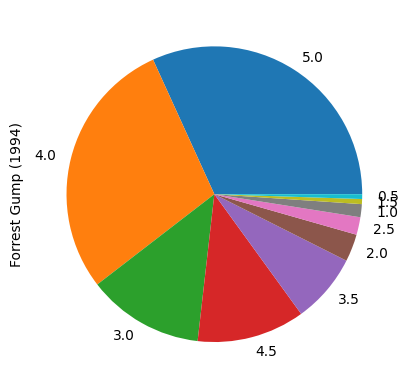

In [ ]:
import matplotlib.pyplot as plt

# Utilizar matplotlib como engine de gráficos porque na integração entre pandas e plotly não tem gráfico de pizza ainda
pd.options.plotting.backend = "matplotlib"

df_pie.plot.pie()

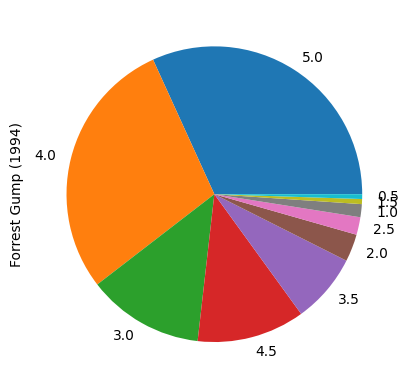

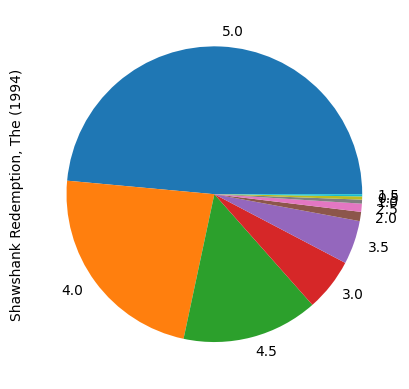

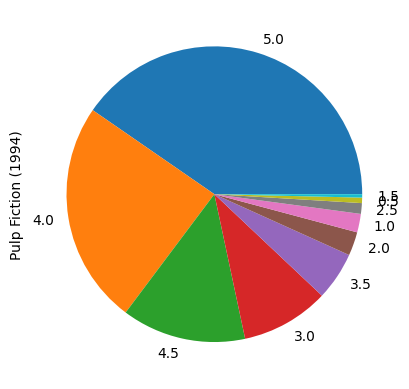

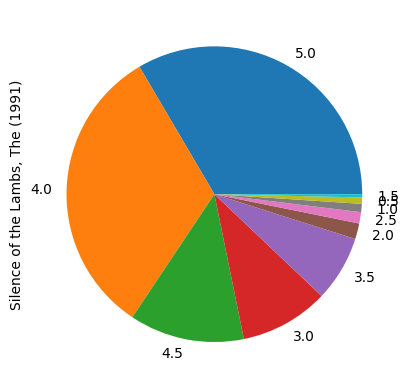

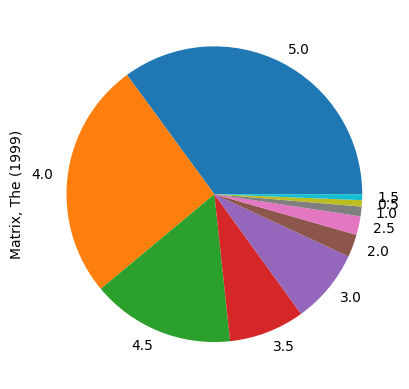

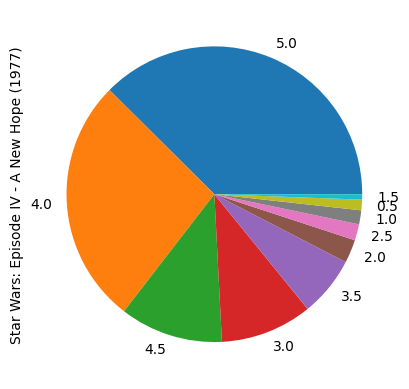

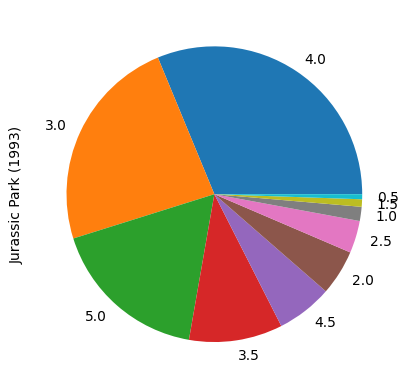

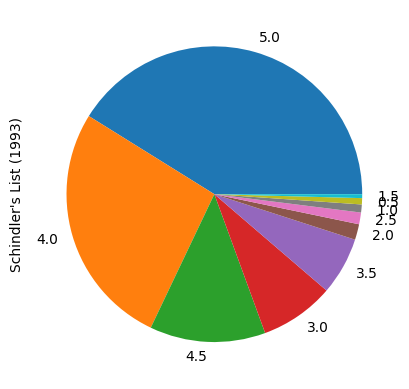

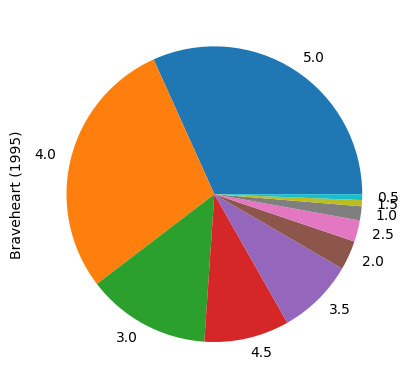

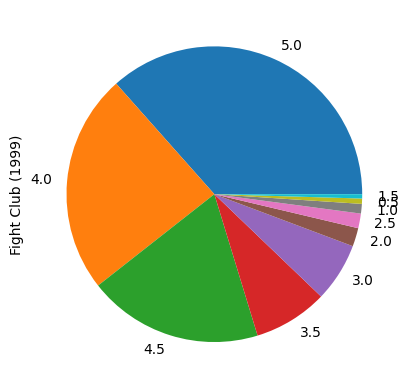

In [ ]:
for movieId in df['movieId'].unique():
    plt.figure()
    df[df['movieId'] == movieId]\
        .set_index('rating')\
        ['ratings_value_count']\
        .rename(df[df['movieId'] == movieId]['title'].iloc[0])\
        .plot.pie()

## Atividade Turma

### Quais são os top 10 filmes com maior quantidade de avaliações com valor 5?

In [ ]:
%%time

df_task = ratings_df[ratings_df['rating'] == 5]\
  .groupby('movieId')\
  ['rating']\
  .count()\
  .rename('count_rating_5')\
  .nlargest(10)
df_task.compute()

CPU times: user 1.43 s, sys: 146 ms, total: 1.58 s
Wall time: 24.5 s


,count_rating_5
movieId,
318,39553
296,32169
356,25918
260,25804
2571,25482
527,24853
593,24801
858,24418
50,21585


In [ ]:
%%time

# Eu não usei o persist na célula anterior. Então ele executa o DAG criado
# com os comandos desde o read_csv do ratings_df e movies_df

movies_df[['movieId', 'title']].merge(
    df_task.reset_index(),
    on='movieId',
    how='inner'
).sort_values(by='count_rating_5', ascending=False)\
  .compute()

CPU times: user 1.26 s, sys: 160 ms, total: 1.42 s
Wall time: 20.4 s


,movieId,title,count_rating_5
3,318,"Shawshank Redemption, The (1994)",39553
2,296,Pulp Fiction (1994),32169
4,356,Forrest Gump (1994),25918
1,260,Star Wars: Episode IV - A New Hope (1977),25804
8,2571,"Matrix, The (1999)",25482
5,527,Schindler's List (1993),24853
6,593,"Silence of the Lambs, The (1991)",24801
7,858,"Godfather, The (1972)",24418
0,50,"Usual Suspects, The (1995)",21585
9,2959,Fight Club (1999),21486


## Quais são os top 10 filmes mais avaliados que são do gênero "Children"?

In [ ]:
movies_df = movies_df.persist() # Guardar merge de filmes com links na memória RAM do cluster
movies_df.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.000000


In [ ]:
len(movies_df)

62423

In [ ]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,296,5.000000,2006-05-17 15:34:04
1,1,306,3.500000,2006-05-17 12:26:57
2,1,307,5.000000,2006-05-17 12:27:08
3,1,665,5.000000,2006-05-17 15:13:40
4,1,899,3.500000,2006-05-17 12:21:50


In [ ]:
len(ratings_df)

25000095

In [ ]:
# Filtrar filmes que são do gênero Children
children_movies_df = movies_df[movies_df['genres'].str.lower().str.contains("children")]
len(children_movies_df)

2935

In [ ]:
# Filtrar avaliações dos filmes que são do gênero Children usando merge
children_movies_ratings_df = ratings_df.merge(children_movies_df, on='movieId', how='inner')
len(children_movies_ratings_df)

2124258

In [ ]:
children_movies_ratings_df.head()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId
0,1,2161,3.500000,2006-05-17 12:23:29,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,88323,34584.000000
1,1,6377,4.000000,2006-05-17 12:21:09,Finding Nemo (2003),Adventure|Animation|Children|Comedy,266543,12.000000
2,1,8360,4.000000,2006-05-17 12:24:42,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Romance,298148,809.000000
3,2,1,3.500000,2006-03-03 19:57:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000
4,2,364,4.500000,2006-03-03 20:17:57,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,110357,8587.000000


In [ ]:
# Calcular os top 10 filmes do gênero Children com maior quantidade de avaliações
df = children_movies_ratings_df.groupby(['movieId', 'title'])\
  ['rating']\
  .count()\
  .rename('ratings_count')\
  .nlargest(10)\
  .compute()
df

,,ratings_count
movieId,title,
1,Toy Story (1995),57309
588,Aladdin (1992),43373
364,"Lion King, The (1994)",42745
4306,Shrek (2001),42303
595,Beauty and the Beast (1991),35723
6377,Finding Nemo (2003),34712
1097,E.T. the Extra-Terrestrial (1982),34602
4886,"Monsters, Inc. (2001)",34572
34,Babe (1995),31456


In [ ]:
# Deixando somente title no index para usar no plot

df = df.reset_index('movieId', drop=True)
df

,ratings_count
title,
Toy Story (1995),57309
Aladdin (1992),43373
"Lion King, The (1994)",42745
Shrek (2001),42303
Beauty and the Beast (1991),35723
Finding Nemo (2003),34712
E.T. the Extra-Terrestrial (1982),34602
"Monsters, Inc. (2001)",34572
Babe (1995),31456


In [ ]:
# Não utilizar matplotlib como engine de gráficos e usar plotly
pd.options.plotting.backend = "plotly"

# Criar uma visualização de gráfico de barras usando pandas e plotly
# Referência: https://pandas.pydata.org/docs/user_guide/visualization.html
df.plot(kind='bar')

## Quantos filmes cada gênero possui?

In [ ]:
movies_df.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.000000


In [ ]:
# Criar a coluna 'genres_list' com a lista de gêneros de cada filme
movies_df['genres_list'] = movies_df['genres'].str.split(pat='|')
movies_df.head()

,movieId,title,genres,imdbId,tmdbId,genres_list
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.000000,[Comedy]


In [ ]:
# Criar uma linha para cada gênero de cada filme
genres_df = movies_df['genres_list'].explode()
genres_df.head(15)

,genres_list
0,Adventure
0,Animation
0,Children
0,Comedy
0,Fantasy
1,Adventure
1,Children
1,Fantasy
2,Comedy
2,Romance


In [ ]:
# Calcular a quantidade de filmes por gênero e mostrar em um gráfico de barras
genres_df.value_counts()\
  .rename('genre')\
  .compute()\
  .sort_values(ascending=False)\
  .plot(kind='bar')

## Atividade Turma

### Quais são as médias de avaliações dos 10 filmes mais avaliados do gênero Drama? Ordene crescente pelas médias.

In [ ]:
drama_movies_df = movies_df[movies_df['genres'].str.contains('Drama')]
len(drama_movies_df)

25606

In [ ]:
drama_movies_ratings_df = ratings_df.merge(drama_movies_df, on='movieId', how='inner')
len(drama_movies_ratings_df)

10962833

In [ ]:
df_task = drama_movies_ratings_df.groupby('movieId')\
    ['rating']\
    .count()\
    .rename('ratings_count')\
    .nlargest(10)\
    .persist()
df_task.compute()

,ratings_count
movieId,
356,81491
318,81482
296,79672
527,60411
110,59184
2959,58773
2858,53689
858,52498
7153,50797


In [ ]:
df_result = drama_movies_ratings_df[drama_movies_ratings_df['movieId'].isin(df_task.compute().index)]\
  .groupby('title')\
  ['rating']\
  .mean()\
  .rename('ratings_mean')\
  .persist()
df_result.compute()

,ratings_mean
title,
American Beauty (1999),4.107340
Apollo 13 (1995),3.873556
Braveheart (1995),4.002273
Fight Club (1999),4.228311
Forrest Gump (1994),4.048011
"Godfather, The (1972)",4.324336
"Lord of the Rings: The Return of the King, The (2003)",4.090340
Pulp Fiction (1994),4.188912
Schindler's List (1993),4.247579


In [ ]:
df_result.compute().sort_values()

,ratings_mean
title,
Apollo 13 (1995),3.873556
Braveheart (1995),4.002273
Forrest Gump (1994),4.048011
"Lord of the Rings: The Return of the King, The (2003)",4.090340
American Beauty (1999),4.107340
Pulp Fiction (1994),4.188912
Fight Club (1999),4.228311
Schindler's List (1993),4.247579
"Godfather, The (1972)",4.324336


## Existe o mesmo gênero aparecendo mais de 1 vez na lista de gêneros do mesmo filme?

In [ ]:
# Criar um novo dataframe com a coluna 'movieId' como índice
movies_idx_df = movies_df.set_index('movieId')\
    .persist()

In [ ]:
movies_idx_df.head()

,title,genres,imdbId,tmdbId,genres_list
movieId,,,,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.000000,"[Adventure, Animation, Children, Comedy, Fantasy]"
2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.000000,"[Adventure, Children, Fantasy]"
3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.000000,"[Comedy, Romance]"
4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.000000,"[Comedy, Drama, Romance]"
5,Father of the Bride Part II (1995),Comedy,113041,11862.000000,[Comedy]


In [ ]:
# Criando o dataframe de gêneros com a coluna 'movieId' como índice. Obs: a coluna 'genres_list' é object
genres_df = movies_idx_df['genres_list'].explode()
genres_df.reset_index().dtypes

,0
movieId,int64
genres_list,object


In [ ]:
genres_df.head()

,genres_list
movieId,
1,Adventure
1,Animation
1,Children
1,Comedy
1,Fantasy


In [ ]:
# Tentar usar a função get_dummies com uma coluna ou Series do dask.dataframe que não seja do tipo category dá erro
genres_df = dd.get_dummies(genres_df)
genres_df.head(10)

NotImplementedError: `get_dummies` with non-categorical dtypes is not supported. Please use `df.categorize()` beforehand to convert to categorical dtype.

In [ ]:
# Tentar converter um Series do dask.dataframe para category dá erro, é necessário usar DataFrame do dask.dataframe
genres_df = genres_df.reset_index()\
    .categorize(columns=['genres_list'])
genres_df.dtypes

,0
movieId,int64
genres_list,category


In [ ]:
genres_df.head(11)

,movieId,genres_list
0,1,Adventure
1,1,Animation
2,1,Children
3,1,Comedy
4,1,Fantasy
5,2,Adventure
6,2,Children
7,2,Fantasy
8,3,Comedy
9,3,Romance


In [ ]:
# Gerar uma coluna para cada categoria com o valor 1 quando o filme possuir o gênero ou 0 caso não possuir
# Para melhorar os nomes das colunas criadas a coluna 'genres_list' está sendo renomeada para 'is_genre'
genres_df = dd.get_dummies(
    genres_df.rename(columns={'genres_list': 'is_genre'})
)
genres_df.head(11)

,movieId,is_genre_(no genres listed),is_genre_Action,is_genre_Adventure,is_genre_Animation,is_genre_Children,is_genre_Comedy,is_genre_Crime,is_genre_Documentary,is_genre_Drama,...,is_genre_Film-Noir,is_genre_Horror,is_genre_IMAX,is_genre_Musical,is_genre_Mystery,is_genre_Romance,is_genre_Sci-Fi,is_genre_Thriller,is_genre_War,is_genre_Western
0,1,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,2,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,3,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,3,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
genres_df.dtypes

,0
movieId,int64
is_genre_(no genres listed),bool
is_genre_Action,bool
is_genre_Adventure,bool
is_genre_Animation,bool
is_genre_Children,bool
is_genre_Comedy,bool
is_genre_Crime,bool
is_genre_Documentary,bool
is_genre_Drama,bool


In [ ]:
# Somar os valores de todas as linhas das novas colunas agrupando por 'movieId'
genres_df = genres_df.groupby('movieId').sum()
genres_df.head()

,is_genre_(no genres listed),is_genre_Action,is_genre_Adventure,is_genre_Animation,is_genre_Children,is_genre_Comedy,is_genre_Crime,is_genre_Documentary,is_genre_Drama,is_genre_Fantasy,is_genre_Film-Noir,is_genre_Horror,is_genre_IMAX,is_genre_Musical,is_genre_Mystery,is_genre_Romance,is_genre_Sci-Fi,is_genre_Thriller,is_genre_War,is_genre_Western
movieId,,,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Não existe repetição de gênero na lista de gêneros dos filmes porque o valor máximo em todos os casos é 1
genres_df.max().compute()

,0
is_genre_(no genres listed),1
is_genre_Action,1
is_genre_Adventure,1
is_genre_Animation,1
is_genre_Children,1
is_genre_Comedy,1
is_genre_Crime,1
is_genre_Documentary,1
is_genre_Drama,1
is_genre_Fantasy,1


In [ ]:
# Caso a lista de gêneros fosse muito grande, seria melhor comprovar isso usando describe
genres_df.max().describe().compute()

,0
count,20.000000
mean,1.000000
std,0.000000
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


## Qual é a estatística da variável 'relevance' do genoma de tag?

In [ ]:
gscores_df.head()

,movieId,tagId,relevance
0,1,1,0.028750
1,1,2,0.023750
2,1,3,0.062500
3,1,4,0.075750
4,1,5,0.140750


In [ ]:
len(gscores_df)

15584448

In [ ]:
gscores_df

,movieId,tagId,relevance
npartitions=6,,,
,int64,int64,float64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [ ]:
%%time

# Calcular a estatística dos valores da coluna 'relevance' usando a função describe
gscores_df['relevance'].describe().compute()

CPU times: user 629 ms, sys: 75.5 ms, total: 705 ms
Wall time: 10.1 s


,relevance
count,15584448.000000
mean,0.116368
std,0.154472
min,0.000250
25%,0.025250
50%,0.061250
75%,0.151250
max,1.000000


## Quais são as top 5 tags mais relevantes do filme 'Matrix, The (1999)' segundo o genoma de tags?

In [ ]:
gtags_df.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


In [ ]:
len(gscores_df)

15584448

In [ ]:
len(gtags_df)

1128

In [ ]:
# Fazer o merge entre os dados de score e tag do genoma de tags

tag_genome_df = dd.merge(gscores_df, gtags_df, on='tagId', how='inner')\
    .persist()
tag_genome_df.head()

,movieId,tagId,relevance,tag
0,1,1,0.028750,007
1,1,2,0.023750,007 (series)
2,1,3,0.062500,18th century
3,1,4,0.075750,1920s
4,1,5,0.140750,1930s


In [ ]:
len(tag_genome_df)

15584448

In [ ]:
# Fazer o merge desses dados com 'movieId' e 'title' do dataset de filmes

movies_tag_genome_df = tag_genome_df.merge(
    movies_df[['movieId', 'title']],
    on='movieId',
    how='inner'
)
movies_tag_genome_df.head()

,movieId,tagId,relevance,tag,title
0,1,1,0.028750,007,Toy Story (1995)
1,1,2,0.023750,007 (series),Toy Story (1995)
2,1,3,0.062500,18th century,Toy Story (1995)
3,1,4,0.075750,1920s,Toy Story (1995)
4,1,5,0.140750,1930s,Toy Story (1995)


In [ ]:
len(movies_tag_genome_df)

15584448

In [ ]:
# Calcular as top 5 tags mais relevantes segundo os dados do genoma de tags

movie_name = "Matrix, The (1999)"
movies_tag_genome_df[movies_tag_genome_df['title'] == movie_name]\
  .nlargest(5, columns='relevance')\
  .compute()

,movieId,tagId,relevance,tag,title
336,2571,337,0.995750,dystopic future,"Matrix, The (1999)"
889,2571,890,0.992750,scifi,"Matrix, The (1999)"
279,2571,280,0.991500,cyberpunk,"Matrix, The (1999)"
885,2571,886,0.988500,sci fi,"Matrix, The (1999)"
888,2571,889,0.987500,science fiction,"Matrix, The (1999)"


## Atividade Turma

### Quais são as top 5 tags mais relevantes segundo os dados do genoma de tags dos top 3 filmes mais avaliados?

In [ ]:
df_task = ratings_df['movieId']\
    .value_counts()\
    .rename('ratings_count')\
    .nlargest(3)\
    .compute()
df_task

,ratings_count
movieId,
356,81491
318,81482
296,79672


In [ ]:
movies_tag_genome_df.head()

,movieId,tagId,relevance,tag,title
0,1,1,0.028750,007,Toy Story (1995)
1,1,2,0.023750,007 (series),Toy Story (1995)
2,1,3,0.062500,18th century,Toy Story (1995)
3,1,4,0.075750,1920s,Toy Story (1995)
4,1,5,0.140750,1930s,Toy Story (1995)


In [ ]:
def get_top_5_tags(dataset: pd.DataFrame) -> pd.DataFrame:
  return dataset.nlargest(5, columns='relevance')

movies_tag_genome_df[movies_tag_genome_df['movieId'].isin(df_task.index)]\
  .groupby('movieId')\
  .apply(get_top_5_tags,
         meta={'movieId': np.dtype('int64'),
              'tagId': np.dtype('int64'),
              'relevance': np.dtype('float64'),
              'tag': np.dtype('O'),
              'title': np.dtype('O')})\
  .compute()

movieId  tagId  relevance  \
movieId                                   
296     509       296    510   0.999250   
        462       296    463   0.990500   
        288       296    289   0.984500   
        633       296    634   0.983500   
        535       296    536   0.983250   
356     3009      356    754   1.000000   
        3007      356    752   0.999750   
        3011      356    756   0.991000   
        3006      356    751   0.982000   
        2554      356    299   0.976250   
318     1663      318    536   0.984250   
        1883      318    756   0.980750   
        1933      318    806   0.977500   
        1761      318    634   0.973500   
        1940      318    813   0.972250   

                                                tag  \
movieId                                               
296     509                                 hit men   
        462                     gratuitous violence   
        288                              dark humor   
        633                             masterpiece   
        535                            imdb top 250   
356     3009    oscar (best music - original score)   
        3007  oscar (best effects - visual effects)   
        3011                   oscar (best picture)   
        3006                   oscar (best editing)   
        2554                                destiny   
318     1663                           imdb top 250   
        1883                   oscar (best picture)   
        1933                        powerful ending   
        1761                            masterpiece   
        1940                                 prison   

                                         title  
movieId                                         
296     509                Pulp Fiction (1994)  
        462                Pulp Fiction (1994)  
        288                Pulp Fiction (1994)  
        633                Pulp Fiction (1994)  
        535                Pulp Fiction (1994)  
356     3009               Forrest Gump (1994)  
        3007               Forrest Gump (1994)  
        3011               Forrest Gump (1994)  
        3006               Forrest Gump (1994)  
        2554               Forrest Gump (1994)  
318     1663  Shawshank Redemption, The (1994)  
        1883  Shawshank Redemption, The (1994)  
        1933  Shawshank Redemption, The (1994)  
        1761  Shawshank Redemption, The (1994)  
        1940  Shawshank Redemption, The (1994)